In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load Data
df = pd.read_csv('../data/processed/city_daily_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Encode season and city as numbers
le_season = LabelEncoder()
le_city = LabelEncoder()

df['season_enc'] = le_season.fit_transform(df['season'])
df['city_enc'] = le_city.fit_transform(df['city'])

print("Shape:", df.shape)
print("Cities:", df['city'].unique())
print(df.head())

Shape: (19018, 19)
Cities: <StringArray>
['Bengaluru', 'Delhi', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
        city       date  month  day_of_week  year  quarter  season       PM25  \
0  Bengaluru 2010-01-01      1            4  2010        1  Winter  45.680481   
1  Bengaluru 2010-01-02      1            5  2010        1  Winter  45.680481   
2  Bengaluru 2010-01-03      1            6  2010        1  Winter  51.230321   
3  Bengaluru 2010-01-04      1            0  2010        1  Winter  51.230321   
4  Bengaluru 2010-01-05      1            1  2010        1  Winter  51.230321   

        PM10         NO        NO2        NOx        NH3       SO2        CO  \
0  89.866905   4.014167  19.772083  23.767917  26.069167  1.652000  0.699583   
1  89.866905   5.620625  22.989583  28.594375  25.741042  2.825000  0.695625   
2  92.751640   6.998417  30.434917  37.413889  15.048651  1.764325  0.771427   
3  92.751640  11.967222  31.255972  43.212083  24.080595  6.145159  0.610364   
4  9

In [3]:
# Features for source analysis
# These represent different pollution sources
feature_cols = [
    'PM10',       # Dust, construction
    'NO',         # Vehicle emissions
    'NO2',        # Vehicle + industrial
    'NOx',        # Combined nitrogen oxides
    'NH3',        # Agriculture, waste
    'SO2',        # Industrial, power plants
    'CO',         # Incomplete combustion, vehicles
    'Ozone',      # Secondary pollutant
    'Benzene',    # Fuel combustion
    'month',      # Seasonal pattern
    'day_of_week',# Traffic pattern
    'season_enc', # Season effect
    'city_enc'    # City specific factors
]

target = 'PM25'

# Drop rows where PM25 is null
df_model = df[feature_cols + [target]].dropna()

print("Rows after dropping nulls:", len(df_model))
print("Features:", feature_cols)

Rows after dropping nulls: 15246
Features: ['PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene', 'month', 'day_of_week', 'season_enc', 'city_enc']


In [4]:
# Train and Test Split
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (12196, 13)
Test size: (3050, 13)


In [5]:
# Train XGBOOST Model
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Results:")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAE  : {mae_xgb:.2f}")
print(f"R2   : {r2_xgb:.4f}")

[0]	validation_0-rmse:51.17455
[50]	validation_0-rmse:16.25799
[100]	validation_0-rmse:14.54986
[150]	validation_0-rmse:14.00679
[200]	validation_0-rmse:13.71978
[250]	validation_0-rmse:13.59765
[299]	validation_0-rmse:13.44135

XGBoost Results:
RMSE : 13.44
MAE  : 6.92
R2   : 0.9367


In [6]:
# Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R2   : {r2_rf:.4f}")

Random Forest Results:
RMSE : 14.28
MAE  : 7.24
R2   : 0.9285


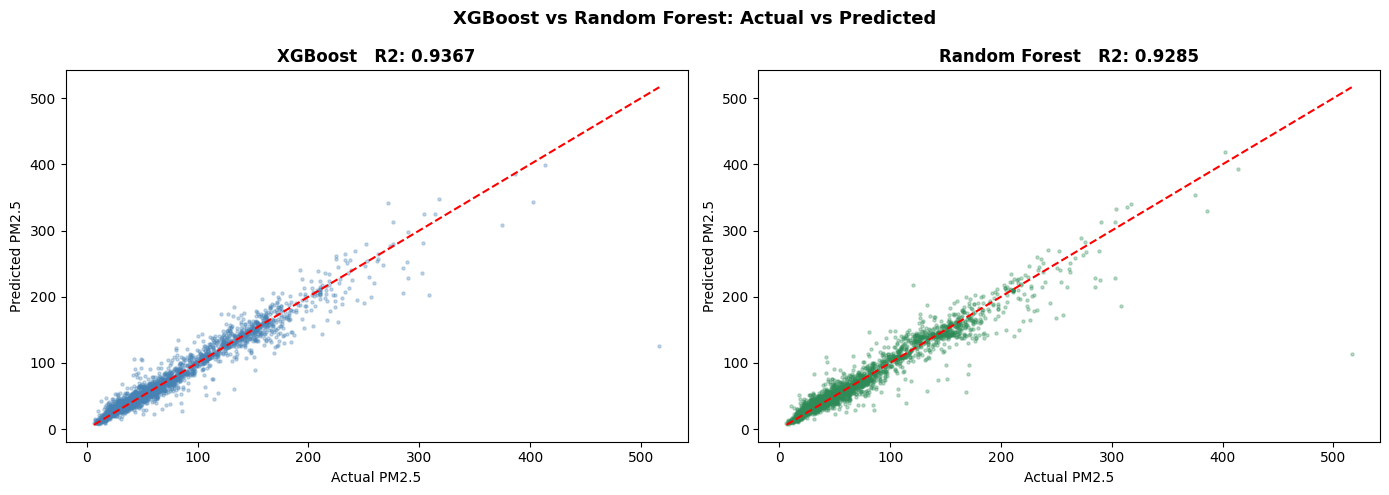

In [8]:
# Compare both Models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost predictions vs actual
axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, color='steelblue', s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'XGBoost   R2: {r2_xgb:.4f}', fontweight='bold')
axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')

# Random Forest predictions vs actual
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen', s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'Random Forest   R2: {r2_rf:.4f}', fontweight='bold')
axes[1].set_xlabel('Actual PM2.5')
axes[1].set_ylabel('Predicted PM2.5')

plt.suptitle('XGBoost vs Random Forest: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

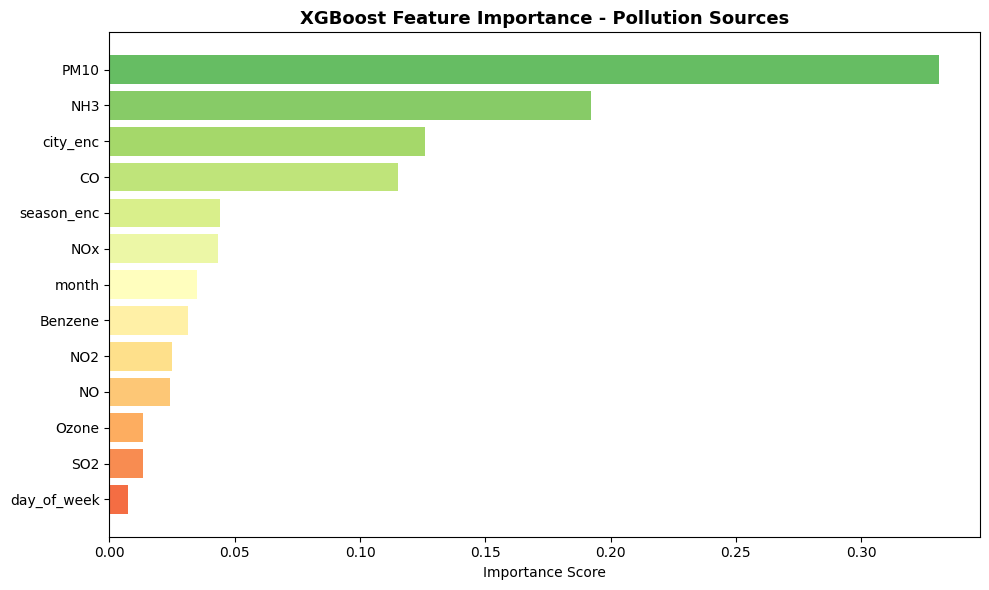

XGBoost Feature Importance:
PM10           0.330873
NH3            0.192086
city_enc       0.125868
CO             0.115018
season_enc     0.043945
NOx            0.043132
month          0.034909
Benzene        0.031329
NO2            0.024974
NO             0.024187
Ozone          0.013217
SO2            0.013215
day_of_week    0.007246
dtype: float32


In [9]:
# Feature importance from XGBoost
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(xgb_importance)))
plt.barh(xgb_importance.index[::-1], xgb_importance.values[::-1], color=colors[::-1])
plt.title('XGBoost Feature Importance - Pollution Sources', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("XGBoost Feature Importance:")
print(xgb_importance)

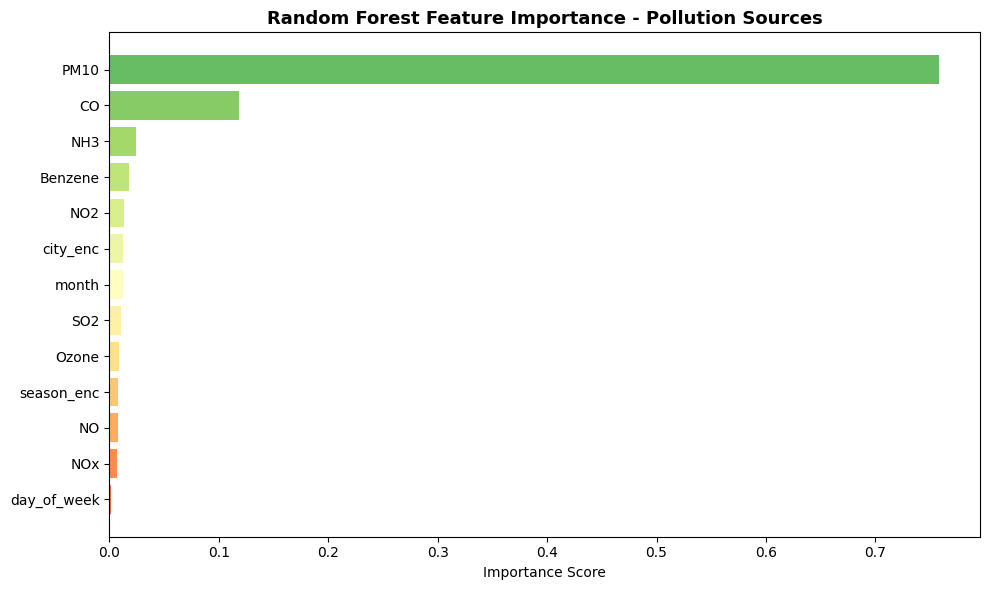

Random Forest Feature Importance:
PM10           0.757733
CO             0.117943
NH3            0.024640
Benzene        0.017692
NO2            0.013665
city_enc       0.012599
month          0.012481
SO2            0.010487
Ozone          0.008910
season_enc     0.008183
NO             0.007785
NOx            0.006629
day_of_week    0.001252
dtype: float64


In [10]:
# Feature importance from Random Forest
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rf_importance)))
plt.barh(rf_importance.index[::-1], rf_importance.values[::-1], color=colors[::-1])
plt.title('Random Forest Feature Importance - Pollution Sources', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Random Forest Feature Importance:")
print(rf_importance)

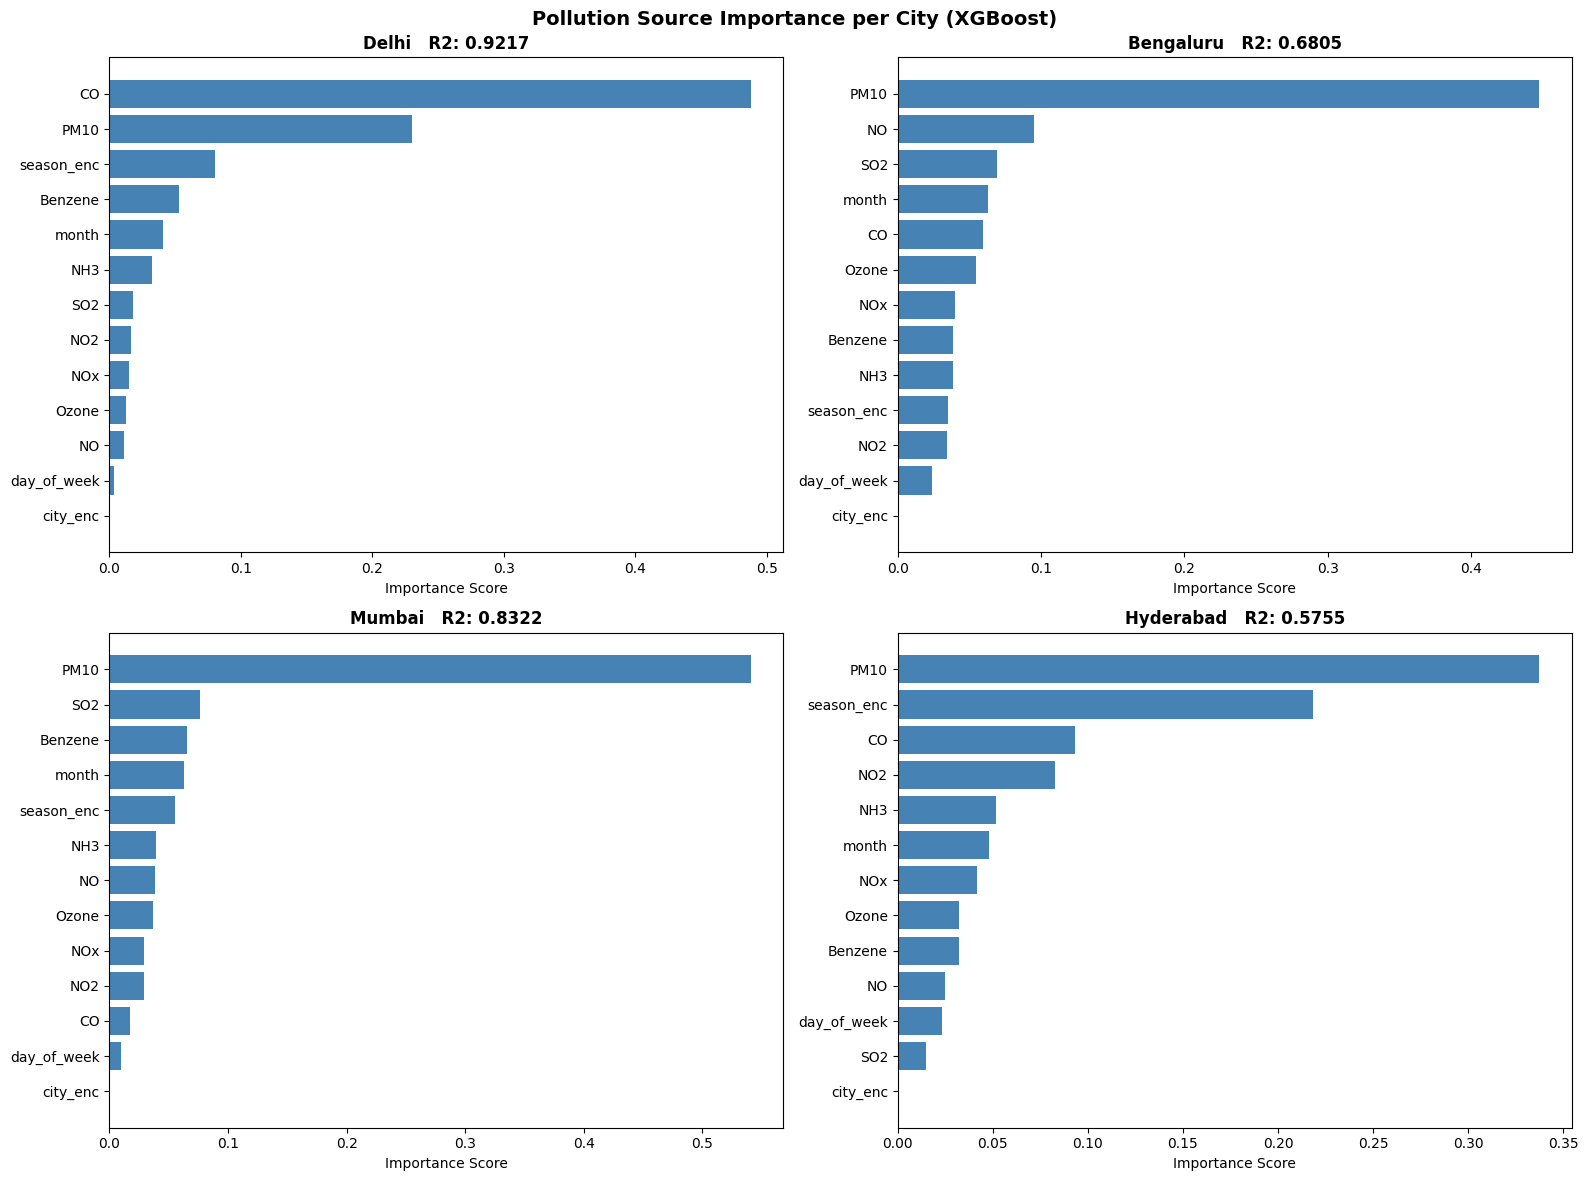

In [11]:
# Feature importance per city
cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
city_importances = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, city in zip(axes.flatten(), cities):
    city_df = df[df['city'] == city][feature_cols + [target]].dropna()
    
    X_city = city_df[feature_cols]
    y_city = city_df[target]
    
    X_tr, X_te, y_tr, y_te = train_test_split(X_city, y_city, test_size=0.2, random_state=42)
    
    city_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42, verbosity=0)
    city_xgb.fit(X_tr, y_tr)
    
    importance = pd.Series(city_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
    city_importances[city] = importance
    
    r2 = r2_score(y_te, city_xgb.predict(X_te))
    
    ax.barh(importance.index[::-1], importance.values[::-1], color='steelblue')
    ax.set_title(f'{city}   R2: {r2:.4f}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Pollution Source Importance per City (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Save Models
import os
os.makedirs('../src/models', exist_ok=True)

# Save XGBoost
xgb_model.save_model('../src/models/xgboost_source.json')
print("XGBoost model saved")

# Save Random Forest
with open('../src/models/random_forest_source.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Random Forest model saved")

# Save city importances
with open('../src/models/city_importances.pkl', 'wb') as f:
    pickle.dump(city_importances, f)
print("City importances saved")

print("\nFinal Comparison:")
print(f"XGBoost    - RMSE: {rmse_xgb:.2f}  MAE: {mae_xgb:.2f}  R2: {r2_xgb:.4f}")
print(f"Random Forest - RMSE: {rmse_rf:.2f}  MAE: {mae_rf:.2f}  R2: {r2_rf:.4f}")

XGBoost model saved
Random Forest model saved
City importances saved

Final Comparison:
XGBoost    - RMSE: 13.44  MAE: 6.92  R2: 0.9367
Random Forest - RMSE: 14.28  MAE: 7.24  R2: 0.9285
